# Suzipu Model Training

If necessary, install the required packages in `requirements.txt` via `pip`.

Make sure that the cell below loads without error message.

In [1]:
from dataclasses import dataclass
import numpy as np
import os
import random
import torch
import torchvision.transforms as transforms

if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from model import *
from stats import *
from suzipu import *

BATCH_SIZE = 100

In [2]:
# Extract data from KuiSCIMA dataset
extract_data()

# Set seeds
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Data Augmentations for Training

In [3]:
total_dataset = open_suzipu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset)

## Normalizes the dataset to have mean 0 and standard deviation of 1
#mean_list = torch.Tensor([torch.Tensor(entry["image"]).mean() for entry in total_dataset])/255
#mean = mean_list.mean()
#std = mean_list.std()

def normalize():
    return transforms.Normalize(mean=0.7102, std=0.0914)

def get_train_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    train_transforms = transforms.Compose([
        erode(percentage=0.2), # causes the notation to be thicker
        dilate(percentage=0.2), # causes the notation to be thinner
        transforms.ToTensor(), # convert from uint8 to [0, 1]
        shrink(is_random=True, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        salt_and_pepper(percentage=0.8), # introduces salt-and-pepper-noise
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        transforms.RandomRotation(degrees=(-9, 9)), # randomly rotate between -12 and 12 degrees
        #lambda img: transforms.functional.invert(img), # inverts image to original color scheme
        normalize(), # normalize mean and variance
    ])
    return train_transforms


def get_validation_transforms(image_size=48):
    target_shrink = image_size - 8
    target_paste = image_size
    validation_transforms = transforms.Compose([
        transforms.ToTensor(),
        shrink(is_random=False, target_size=target_shrink),
        paste_to_square(is_random=False, target_size=target_paste),
        lambda img: transforms.functional.invert(img), # inverts image, needed for rotations
        normalize(), # normalize mean and variance
    ])
    return validation_transforms


def get_test_transforms(image_size=48):
    return get_validation_transforms(image_size=image_size)

transformations = {
    "train": get_train_transforms,
    "validation": get_validation_transforms,
    "test": get_test_transforms
}

# Dataset and Dataloader functions

In [4]:
def get_distribution(dataset, num_classes, get_absolute=False):
    classes, weights = np.unique(dataset, return_counts=True)  # here, only get total dataset distribution!
    weights_dict = {}
    for cls, w in zip(classes, weights):
        weights_dict[cls] = w
    distr = []  # must pad so we get to all 77 classes
    for idx in range(num_classes):
        if idx in classes:
            distr.append(weights_dict[idx])
        else:
            distr.append(0)
    if not get_absolute:
        distr /= sum(distr)
    return distr

REAL_TOTAL_DISTRIBUTION = torch.Tensor(get_distribution([individual_labels_to_class(entry["annotation"]["pitch"], entry["annotation"]["secondary"]) for entry in total_dataset], num_classes=77))

# Load Data and Make Visualization

In [5]:
total_dataloaders = get_all_dataloaders(total_dataset, transformations=transformations)

In [6]:
print(len(total_dataloaders["pitch_balanced"]["train"]))
print(len(total_dataloaders["pitch_balanced"]["validation"]))
print(len(total_dataloaders["pitch_balanced"]["test"]))

43
15
15


/tmp/ipykernel_283938/2383384586.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


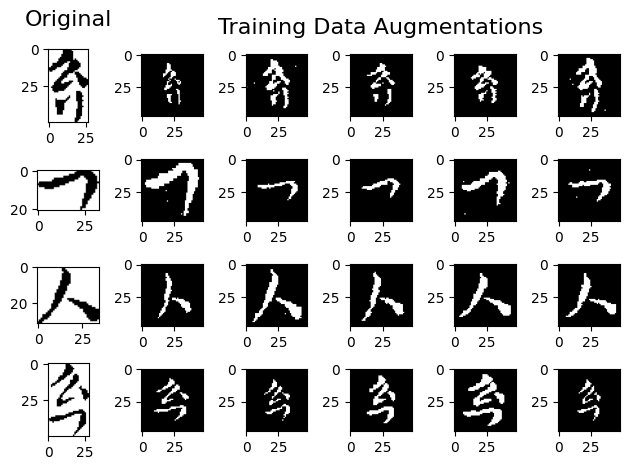

In [7]:
# take a sample and visualize some data augmentations

start_idx = 0

rows, cols = 4, 6
fig, axs = plt.subplots(rows, cols)
fig.tight_layout()
#fig.suptitle('Horizontally stacked subplots')
for row in range(rows):
    if row == 0:
        axs[0][0].set_title("Original", fontsize=16, y=1.2)
        axs[0][3].set_title("Training Data Augmentations", fontsize=16, y=1.2)
    
    axs[row][0].imshow(total_dataset[start_idx+row]["image"], cmap="gray")
        
    for col in range(cols-1):
        col += 1
        axs[row][col].imshow(get_train_transforms()(total_dataset[start_idx+row]["image"])[0], cmap="gray")
fig.show()
fig.tight_layout()
fig.savefig("training_data_augmentations.pdf", format="pdf", bbox_inches="tight")

/tmp/ipykernel_283938/1485928967.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


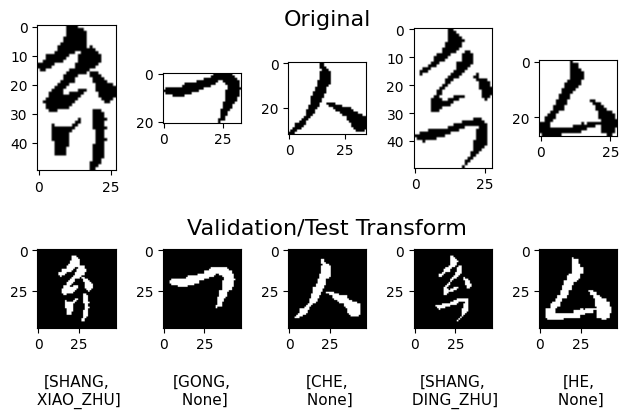

In [8]:
# take a sample and visualize some data augmentations
start_idx = 0

rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols)
fig.tight_layout()
#fig.suptitle('Horizontally stacked subplots')
for row in range(rows):
    if row == 0:
        axs[0][cols//2].set_title("Original", fontsize=16, y=1.4)
        axs[1][cols//2].set_title("Validation/Test Transform", fontsize=16, y=1.1)
    
    for col in range(cols):
        axs[0][col].imshow(total_dataset[start_idx+col]["image"], cmap="gray")
        axs[1][col].imshow(get_validation_transforms()(total_dataset[start_idx+col]["image"])[0], cmap="gray")
        primary = class_to_annotation["pitch"][total_dataset[start_idx+col]["annotation"]["pitch"]]
        secondary = class_to_annotation["secondary"][total_dataset[start_idx+col]["annotation"]["secondary"]]
        axs[1][col].set_xlabel(f'\n[{primary},\n {secondary}]', size=11)

        
fig.show()
fig.tight_layout()
fig.savefig("validation_data_augmentations.pdf", format="pdf", bbox_inches="tight")

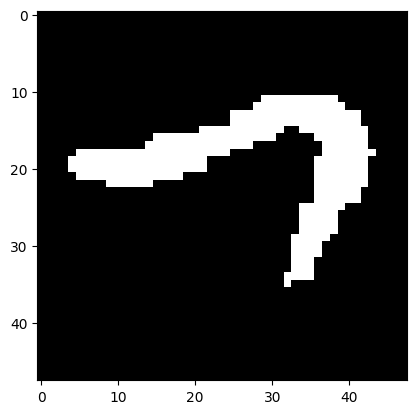

In [9]:
plt.imshow(get_validation_transforms()(total_dataset[1]["image"])[0], cmap="gray")
plt.imsave("example.png", get_validation_transforms()(total_dataset[1]["image"])[0], cmap="gray")

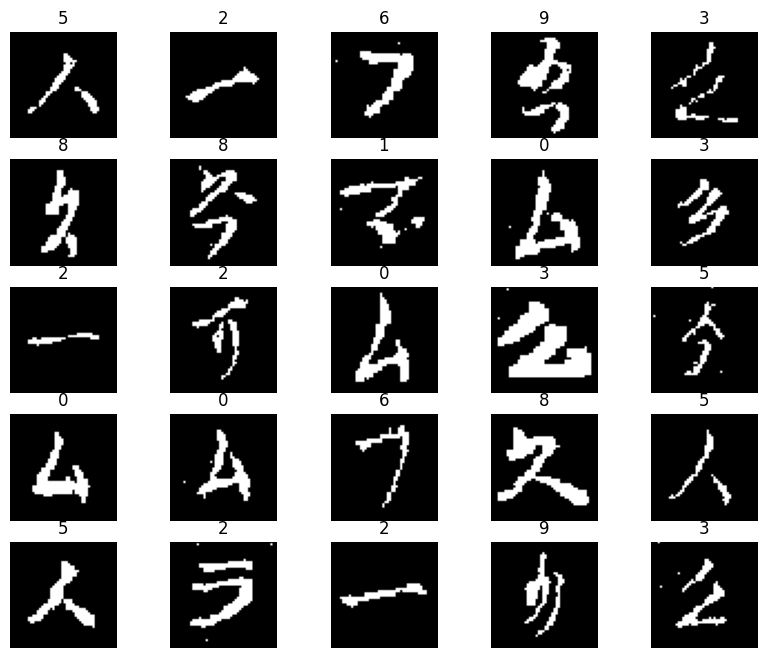

In [10]:
# visualize pitch training data (Lu edition is excluded from training data)
visualize_dataloader(total_dataloaders[LabelType.PITCH_BALANCED]["train"])

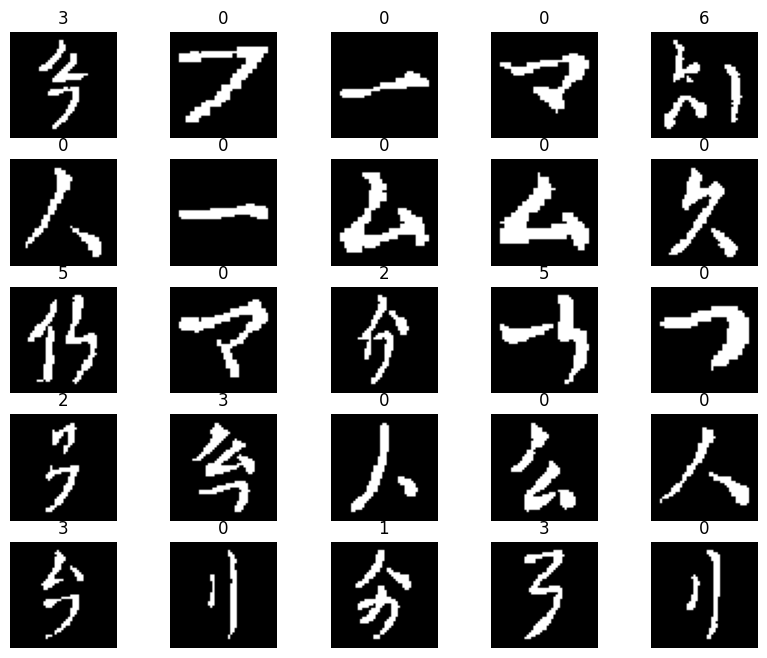

In [11]:
# visualize secondary validation data (Lu edition)
visualize_dataloader(total_dataloaders[LabelType.SECONDARY_BALANCED]["validation"])

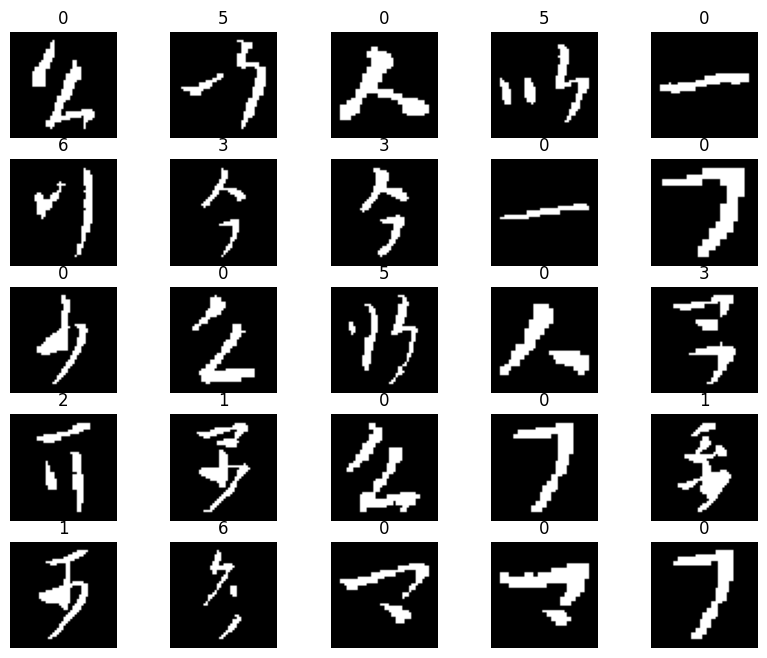

In [12]:
# visualize secondary validation data (Lu edition) - Test
visualize_dataloader(total_dataloaders[LabelType.SECONDARY_BALANCED]["test"])

# Define Training and Validation Functions

In [13]:
MODEL_FOLDER = "suzipu_models"
if not os.path.exists(MODEL_FOLDER):
    os.mkdir(MODEL_FOLDER)

In [14]:
from torch import optim
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau


def loss_function(x, y, label_type, gamma):
    return FocalLoss(gamma=gamma)(x, y)
    #return nn.NLLLoss()(x, y)


def train(num_epochs, model, loaders, LABEL_TYPE, do_validate=False, hyperparameters=None):
    print(hyperparameters)
    best_model = None
    max_validate = 0
    best_epoch = 0

    train_accuracies = []
    val_accuracies = []
    test_accuracies = []
    
    model.to(device)
    model.train()
        
    # Train the model
    total_step = len(loaders['train'])

    decay_params = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if 'bias' in name or 'bn' in name or isinstance(param, nn.BatchNorm2d):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    if not hyperparameters:
        lr = 0.01
        weight_decay = 1e-3
        optimizer = "SGD"
        momentum = 0.9
        gamma = 3
        lr_factor = 0.8
        lr_patience = 10
        image_size = 48
    else:
        lr = hyperparameters[LABEL_TYPE]["lr"]
        weight_decay = hyperparameters[LABEL_TYPE]["weight_decay"]
        optimizer = hyperparameters[LABEL_TYPE]["optimizer"]
        momentum = hyperparameters[LABEL_TYPE]["momentum"]
        gamma = hyperparameters[LABEL_TYPE]["gamma"]
        lr_factor = hyperparameters[LABEL_TYPE]["lr_factor"]
        lr_patience = hyperparameters[LABEL_TYPE]["lr_patience"]
        image_size = hyperparameters[LABEL_TYPE]["image_size"]

    #optimizer = optim.Adam(model.parameters(), lr=0.001)
    if optimizer == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam([{"params": decay_params, "weight_decay": weight_decay}, {"params": no_decay_params, "weight_decay": 0}], lr=lr, amsgrad=True)

    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=lr_factor, patience=lr_patience)

    print(f"Training with", LABEL_TYPE)

    total_count_all = 0
    total_count_simple = 0
    total_count_composite = 0

    total_correct_all = 0
    total_correct_simple = 0
    total_correct_composite = 0
    
        
    for epoch in range(num_epochs):
        for i, (images, labels, is_simple) in enumerate(loaders['train']):
            images, is_simple = images.to(device), is_simple.to(device)
            labels = labels.to(device)
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)
            
            output = model(b_x)
            
            loss = loss_function(output, b_y, LABEL_TYPE, gamma=gamma)
            
            # clear gradients for this training step   
            optimizer.zero_grad()
            #backpropagation, compute gradients 
            loss.backward()                # apply gradients  
            optimizer.step()
            
            pred_y = torch.argmax(output, dim=1)              
            total_accuracy = (pred_y == labels).sum() / float(len(pred_y))
            total_count_all += float(len(pred_y))
            total_correct_all += (pred_y == labels).sum()
            
            pred_y_composite = torch.Tensor([pred_y[idx] for idx in range(len(pred_y)) if not is_simple[idx]])
            labels_composite = torch.Tensor([labels[idx] for idx in range(len(pred_y)) if not is_simple[idx]])
            total_count_composite = len(pred_y_composite)
            total_correct_composite = (pred_y_composite == labels_composite).sum()
            composite_accuracy = (pred_y_composite == labels_composite).sum() / len(pred_y_composite) 
            
            pred_y_simple = torch.Tensor([pred_y[idx] for idx in range(len(pred_y)) if is_simple[idx]])
            labels_simple = torch.Tensor([labels[idx] for idx in range(len(pred_y)) if is_simple[idx]])
            simple_accuracy = (pred_y_simple == labels_simple).sum() / len(pred_y_simple)
            total_count_simple += len(pred_y_simple)
            total_correct_simple += (pred_y_simple == labels_simple).sum()
                        
            if (i+1) % 100 == 0:
                print ('    Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Acc.(Total): {:.2f}%, Acc.(Simple): {:.2f}%, Acc.(Composite): {:.2f}%'.format(epoch + 1, num_epochs, i + 1, total_step, loss.item(), total_accuracy*100, simple_accuracy*100, composite_accuracy*100))

        print(f"Epoch {epoch+1}/{num_epochs}, Acc. (Total): {total_correct_all/total_count_all*100:.2f}%, Acc. (Simple): {total_correct_composite/total_count_composite*100:.2f}%, Acc. (Composite): {total_correct_simple/total_count_simple*100:.2f}%")
        current_validate, val_loss = validate(model, loaders, LABEL_TYPE, gamma=gamma)
        test_acc, _, _ = test(model, loaders, LABEL_TYPE, gamma=gamma)
        scheduler.step(val_loss)
        #test(model, loaders, LABEL_TYPE)

        train_accuracies.append(total_correct_all/total_count_all)
        val_accuracies.append(current_validate)
        test_accuracies.append(test_acc)
        
        if current_validate > max_validate:
            print("***BEST MODEL***")
            best_model = copy.deepcopy(model)
            best_epoch = epoch
            max_validate = current_validate
        else:
            print(f"best model: {max_validate*100:.2f}, epoch {best_epoch}")
        best_model = copy.deepcopy(model)
                
    return best_model, best_epoch, max_validate, train_accuracies, val_accuracies, test_accuracies

def validate(model, loaders, LABEL_TYPE, gamma):  
    model.to(device)
    model.eval()
        
    # Train the model
    total_step = len(loaders['validation'])
    
    print(f"Validating with")
    print(LABEL_TYPE)
    
    pred_y = []
    full_labels = []
    is_simple_full = []

    val_loss = 0
        
    for i, (images, labels, is_simple) in enumerate(loaders['validation']):
        images, is_simple = images.to(device), is_simple.to(device)
        labels = labels.to(device)

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
        b_y = Variable(labels)

        output = model(b_x)

        val_loss += loss_function(output, b_y, LABEL_TYPE, gamma)
        pred_y += torch.argmax(output, dim=1)
        is_simple_full += is_simple
        full_labels += labels

    val_loss /= len(loaders['validation'])
    
    labels = torch.Tensor(full_labels)
    pred_y = torch.Tensor(pred_y)
    is_simple = torch.Tensor(is_simple_full)
    
    total_accuracy = (pred_y == labels).sum() / float(len(pred_y))
    pred_y_simple = torch.Tensor([pred_y[idx] for idx in range(len(pred_y)) if is_simple[idx]])
    labels_simple = torch.Tensor([labels[idx] for idx in range(len(pred_y)) if is_simple[idx]])
    simple_accuracy = (pred_y_simple == labels_simple).sum() / len(pred_y_simple)   

    pred_y_composite = torch.Tensor([pred_y[idx] for idx in range(len(pred_y)) if not is_simple[idx]])
    labels_composite = torch.Tensor([labels[idx] for idx in range(len(pred_y)) if not is_simple[idx]])
    composite_accuracy = (pred_y_composite == labels_composite).sum() / len(pred_y_composite) 

    print ('    Acc.(Total): {:.2f}%, Acc.(Simple): {:.2f}%, Acc.(Composite): {:.2f}%'.format(total_accuracy*100, simple_accuracy*100, composite_accuracy*100))
    
    return total_accuracy, val_loss

def test(model, test_loader, LABEL_TYPE, gamma=0):  
    model.to(device)
    model.eval()
        
    # Train the model
    total_step = len(test_loader)
    
    print(f"Testing with")
    print(LABEL_TYPE)
    
    pred_y = []
    full_labels = []
    is_simple_full = []
        
    for i, (images, labels, is_simple) in enumerate(test_loader["test"]):
        images, is_simple = images.to(device), is_simple.to(device)
        labels = labels.to(device)

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
        b_y = Variable(labels)

        output = model(b_x)

        loss = loss_function(output, b_y, LABEL_TYPE, gamma)
        pred_y += torch.argmax(output, dim=1)
        is_simple_full += is_simple
        full_labels += labels
    
    labels = torch.Tensor(full_labels)
    pred_y = torch.Tensor(pred_y)

    is_simple = torch.Tensor(is_simple_full)
    
    total_accuracy = (pred_y == labels).sum() / float(len(pred_y))
    pred_y_simple = torch.Tensor([pred_y[idx] for idx in range(len(pred_y)) if is_simple[idx]])
    labels_simple = torch.Tensor([labels[idx] for idx in range(len(pred_y)) if is_simple[idx]])
    simple_accuracy = (pred_y_simple == labels_simple).sum() / len(pred_y_simple)   

    pred_y_composite = torch.Tensor([pred_y[idx] for idx in range(len(pred_y)) if not is_simple[idx]])
    labels_composite = torch.Tensor([labels[idx] for idx in range(len(pred_y)) if not is_simple[idx]])
    composite_accuracy = (pred_y_composite == labels_composite).sum() / len(pred_y_composite) 

    print ('    Acc.(Total): {:.2f}%, Acc.(Simple): {:.2f}%, Acc.(Composite): {:.2f}%'.format(total_accuracy*100, simple_accuracy*100, composite_accuracy*100))
    
    return total_accuracy, pred_y, labels


def double_test(pitch_model, secondary_model, total_loader):  
    pitch_model.to(device)
    pitch_model.eval()

    secondary_model.to(device)
    secondary_model.eval()
        
    # Train the model
    total_step = len(total_loader)
    
    pred_y_pitch = []
    pred_y_secondary = []
    full_labels_pitch = []
    full_labels_secondary = []
    
    is_simple_full = []
        
    for i, (images, labels, is_simple) in enumerate(total_loader["test"]):
        images, is_simple = images.to(device), is_simple.to(device)

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
       
        b_y_pitch = torch.Tensor([label for label in labels["pitch"] ])
        b_y_pitch.to(device)

        b_y_secondary = torch.Tensor([label for label in labels["secondary"]])
        b_y_secondary.to(device)

        output_pitch = pitch_model(b_x)
        output_secondary = secondary_model(b_x)

        pred_y_pitch += torch.argmax(output_pitch, dim=1)
        pred_y_secondary += torch.argmax(output_secondary, dim=1)
        
        
        full_labels_pitch += b_y_pitch
        full_labels_secondary += b_y_secondary
    
    full_labels = torch.stack((torch.Tensor(full_labels_pitch), torch.Tensor(full_labels_secondary)))
    pred_y = torch.stack((torch.Tensor(pred_y_pitch), torch.Tensor(pred_y_secondary)))

    columnwise_equal = torch.all(full_labels == pred_y, dim=0)
    #print(columnwise_equal)
    
    total_accuracy = columnwise_equal.sum() / float(len(columnwise_equal))

    print ('    Acc.(Total): {:.2f}%,'.format(total_accuracy*100))
    
    return total_accuracy


def double_validate(pitch_model, secondary_model, total_loader):  
    pitch_model.to(device)
    pitch_model.eval()

    secondary_model.to(device)
    secondary_model.eval()
        
    # Train the model
    total_step = len(total_loader)
    
    pred_y_pitch = []
    pred_y_secondary = []
    full_labels_pitch = []
    full_labels_secondary = []
    
    is_simple_full = []
        
    for i, (images, labels, is_simple) in enumerate(total_loader["validation"]):
        images, is_simple = images.to(device), is_simple.to(device)

        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
       
        b_y_pitch = torch.Tensor([label for label in labels["pitch"] ])
        b_y_pitch.to(device)

        b_y_secondary = torch.Tensor([label for label in labels["secondary"]])
        b_y_secondary.to(device)

        output_pitch = pitch_model(b_x)
        output_secondary = secondary_model(b_x)

        pred_y_pitch += torch.argmax(output_pitch, dim=1)
        pred_y_secondary += torch.argmax(output_secondary, dim=1)
        
        
        full_labels_pitch += b_y_pitch
        full_labels_secondary += b_y_secondary
    
    full_labels = torch.stack((torch.Tensor(full_labels_pitch), torch.Tensor(full_labels_secondary)))
    pred_y = torch.stack((torch.Tensor(pred_y_pitch), torch.Tensor(pred_y_secondary)))

    columnwise_equal = torch.all(full_labels == pred_y, dim=0)
    #print(columnwise_equal)
    
    total_accuracy = columnwise_equal.sum() / float(len(columnwise_equal))

    print ('    Acc.(Total): {:.2f}%,'.format(total_accuracy*100))
    
    return total_accuracy

def train_and_save_all_models(number_of_trials=10, num_epochs=10, test_edition=Editions.SHANGHAI, hyperparameters=None, offset=0, use_artificial=False):
    for label_type in [LabelType.PITCH_BALANCED, LabelType.SECONDARY_BALANCED]:
        
        if "pitch" in label_type:
            num_output_classes = 11
        else:
            num_output_classes = 7
        
        epoch_acc_list = []
        for idx in range(number_of_trials):
            for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
                total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=hyperparameters[label_type]["image_size"], transformations=transformations)
                print(len(total_dataloaders[label_type]["train"]), len(total_dataloaders[label_type]["validation"]), len(total_dataloaders[label_type]["test"]))
                model, epoch, accuracy, train_accs, val_accs, test_accs = train(num_epochs, CnnModel(num_output_classes, hyperparameters[label_type]["image_size"]), total_dataloaders[label_type], label_type, do_validate=True, hyperparameters=hyperparameters)
                test_accuracy, _, _ = test(model, total_dataloaders[label_type], label_type, gamma=hyperparameters[label_type]["gamma"])
                value_dict = {
                              "state_dict": model.state_dict(), 
                              "val_accuracy": accuracy, 
                              "val_epoch": epoch, 
                              "test_accuracy": test_accuracy,
                              "train_accuracies": train_accs,
                              "val_accuracies": val_accs,
                              "test_accuracies": test_accs,
                             }
            
                torch.save(value_dict, f"{MODEL_FOLDER}/{test_edition}-{label_type}-{idx+offset}.std")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("DEVICE CODE IS EXECUTED ON:", device)

DEVICE CODE IS EXECUTED ON: cpu


# Train for each of the five validation settings (20% of whole data, Lu edition, ...) for each pitch and secondary symbols, and 5 times each with maximum 15 epochs. Take the epoch with the highest accuracy on the validation set.

In [37]:
hyperparameters = {
        "pitch_balanced": {
            "lr": 0.001,
            "gamma": 1,
            "weight_decay": 1e-4,
            "lr_factor": 0.5,
            "lr_patience": 5,
            "optimizer": "Adam",
            "image_size": 48,
            "momentum": 0,
        },
        "secondary_balanced": {
            "lr": 0.001,
            "gamma": 1,
            "weight_decay": 1e-4,
            "lr_factor": 0.5,
            "lr_patience": 5,
            "optimizer": "Adam",
            "image_size": 48,
            "momentum": 0,
        }
    }

model_dict = train_and_save_all_models(number_of_trials=10, num_epochs=80, hyperparameters=hyperparameters, offset=0)

tensor(0.9773)


/tmp/ipykernel_619866/2083844455.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{label_type}-{idx}.std", map_locatio

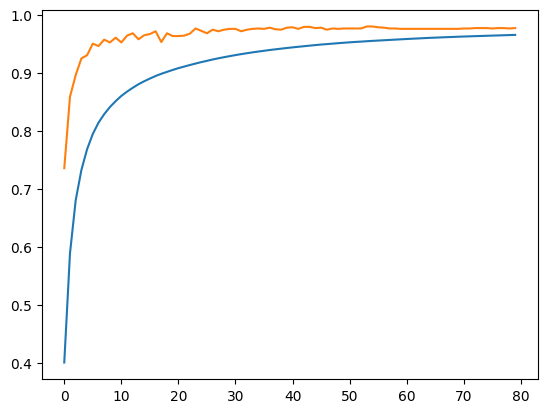

In [38]:
folder = "."
test_edition = "zhu"
use_artificial = False
label_type = LabelType.PITCH_BALANCED
idx = 1

file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{label_type}-{idx}.std", map_location=torch.device('cpu'))

plt.plot(file["train_accuracies"])
plt.plot(file["val_accuracies"])
print(file["val_accuracies"][-1])

/tmp/ipykernel_619866/2514575730.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{label_type}-{idx}.std", map_locatio

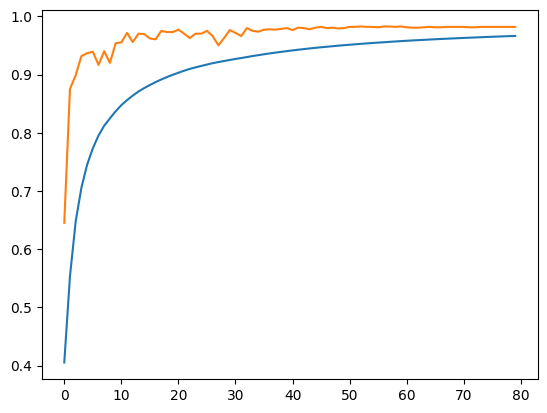

In [39]:
test_edition = "zhu"
use_artificial = False
label_type = LabelType.SECONDARY_BALANCED
idx = 0

file = torch.load(f"./{MODEL_FOLDER}/{test_edition}-{label_type}-{idx}.std", map_location=torch.device('cpu'))

plt.plot(file["train_accuracies"])
plt.plot(file["val_accuracies"])

# Make statistics

In [15]:
def open_model_stats(folder, use_artificial, label_type, number_of_trials, validation_edition=None):
    validation_model_dict = {}
    test_model_dict = {}
    
    for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
        validation_model_dict[test_edition] = []
        test_model_dict[test_edition] = []
        for idx in range(number_of_trials):
            file = torch.load(f"{folder}/{test_edition}-{label_type}-{idx}.std", map_location=torch.device('cpu'))
            validation_model_dict[test_edition].append(file["val_accuracies"][-1])
            test_model_dict[test_edition].append(file["test_accuracies"][-1])
    return validation_model_dict, test_model_dict

NUM_MODELS = 10
BEST_MODELS = 5

model_1_val_pitch, model_1_test_pitch = open_model_stats(MODEL_FOLDER, False, "pitch_balanced", NUM_MODELS)
model_1_val_secondary, model_1_test_secondary = open_model_stats(MODEL_FOLDER, False, "secondary_balanced", NUM_MODELS)

import numpy as np
from scipy.stats import pearsonr, spearmanr

highest_pitch_indices = {}
highest_secondary_indices = {}
for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
    highest_pitch_indices[test_edition] = sorted(range(len(model_1_val_pitch[test_edition])), key=lambda x: model_1_val_pitch[test_edition][x], reverse=True)[0:BEST_MODELS]
    highest_secondary_indices[test_edition] = sorted(range(len(model_1_val_secondary[test_edition])), key=lambda x: model_1_val_secondary[test_edition][x], reverse=True)[0:BEST_MODELS]

print(model_1_val_pitch)
print(model_1_test_pitch)
print(highest_secondary_indices)

print(f"Spearman's correlation for pitch: {spearmanr(model_1_val_pitch[Editions.SHANGHAI], model_1_test_pitch[Editions.SHANGHAI])[0]}")
print(f"Spearman's correlation for secondary: {spearmanr(model_1_val_secondary[Editions.SHANGHAI], model_1_test_secondary[Editions.SHANGHAI])[0]}")

/tmp/ipykernel_283938/3711449488.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"{folder}/{test_edition}-{label_type}-{idx}.std", map_location=torch.

{'lu': [tensor(0.9732), tensor(0.9650), tensor(0.9670), tensor(0.9615), tensor(0.9760), tensor(0.9712), tensor(0.9691), tensor(0.9773), tensor(0.9718), tensor(0.9684)], 'zhang': [tensor(0.9704), tensor(0.9779), tensor(0.9676), tensor(0.9766), tensor(0.9690), tensor(0.9711), tensor(0.9711), tensor(0.9779), tensor(0.9766), tensor(0.9683)], 'siku': [tensor(0.9656), tensor(0.9704), tensor(0.9732), tensor(0.9718), tensor(0.9704), tensor(0.9683), tensor(0.9718), tensor(0.9677), tensor(0.9697), tensor(0.9656)], 'zhu': [tensor(0.9766), tensor(0.9773), tensor(0.9677), tensor(0.9711), tensor(0.9663), tensor(0.9691), tensor(0.9636), tensor(0.9766), tensor(0.9739), tensor(0.9684)], 'shanghai': [tensor(0.9621), tensor(0.9697), tensor(0.9663), tensor(0.9780), tensor(0.9683), tensor(0.9711), tensor(0.9697), tensor(0.9656), tensor(0.9704), tensor(0.9745)]}
{'lu': [tensor(0.9637), tensor(0.9588), tensor(0.9686), tensor(0.9637), tensor(0.9609), tensor(0.9609), tensor(0.9700), tensor(0.9700), tensor(0.96

In [55]:
def conduct_double_test(folder, use_artificial):
    total_accs = {}

    def get_best_model(label_type, test_edition):
        num_classes = 11 if "pitch" in label_type else 7
        model = CnnModel(num_classes)
        max_validation = 0
        for idx in highest_pitch_indices[test_edition] if "pitch" in label_type else highest_secondary_indices[test_edition]:
            file = torch.load(f"./{folder}/{test_edition}-{label_type}-{idx}.std", map_location=torch.device('cpu'))
            validation = file["val_accuracies"][-1]
            if validation > max_validation:
                max_validation = validation
                max_validation_test = file["test_accuracies"][-1]
                model.load_state_dict(file["state_dict"])
                best_file = file

        torch.save(best_file["state_dict"], f"{MODEL_FOLDER}/suzipu-best-{test_edition}-{label_type}.std")
        return model, max_validation, max_validation_test

    for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
        total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=48, transformations=transformations)
        pitch_model, pitch_validation, pitch_test = get_best_model("pitch_balanced", test_edition)
        secondary_model, secondary_validation, secondary_test = get_best_model("secondary_balanced", test_edition)
    
        acc = double_test(pitch_model, secondary_model, total_dataloaders["full"])
        total_accs[test_edition] = {
            "total_acc": acc,
            "pitch_validation": pitch_validation, "pitch_test": pitch_test,
            "secondary_validation": secondary_validation, "secondary_test": secondary_test
        }
                                    
    return total_accs

def conduct_double_test_with_validation(folder, use_artificial):
    total_accs = {}

    for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
        total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=48, transformations=transformations)

        pitch_model = CnnModel(11)
        secondary_model = CnnModel(7)
        total_accs[test_edition] = {
            "total": [],
            "pitch": [],
            "secondary": [],
            "val_pitch": [],
            "val_secondary": []
        }
        for idx1 in highest_pitch_indices[test_edition]:
            for idx2 in highest_secondary_indices[test_edition]:
                pitch_file = torch.load(f"./{folder}/{test_edition}-pitch_balanced-{idx1}.std", map_location=torch.device('cpu'))
                secondary_file = torch.load(f"./{folder}/{test_edition}-secondary_balanced-{idx2}.std", map_location=torch.device('cpu'))
                pitch_model.load_state_dict(pitch_file["state_dict"])
                secondary_model.load_state_dict(secondary_file["state_dict"])
                acc = double_test(pitch_model, secondary_model, total_dataloaders["full"])
                total_accs[test_edition]["total"].append(acc)

        for idx1, idx2 in zip(highest_pitch_indices[test_edition], highest_secondary_indices[test_edition]):
            pitch_file = torch.load(f"./{folder}/{test_edition}-pitch_balanced-{idx1}.std", map_location=torch.device('cpu'))
            secondary_file = torch.load(f"./{folder}/{test_edition}-secondary_balanced-{idx2}.std", map_location=torch.device('cpu'))
            total_accs[test_edition]["pitch"].append(pitch_file["test_accuracies"][-1])
            total_accs[test_edition]["secondary"].append(secondary_file["test_accuracies"][-1])
            total_accs[test_edition]["val_pitch"].append(pitch_file["val_accuracies"][-1])
            total_accs[test_edition]["val_secondary"].append(secondary_file["val_accuracies"][-1])
        
                                    
    return total_accs

def conduct_double_test_all(folder, use_artificial):
    total_accs = {}

    for test_edition in [Editions.LU, Editions.ZHANG, Editions.SIKU, Editions.ZHU, Editions.SHANGHAI]:
        total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=48, transformations=transformations)

        pitch_model = CnnModel(11)
        secondary_model = CnnModel(7)
        total_accs[test_edition] = {
            "total": [],
            "pitch": [],
            "secondary": [],
            "val_pitch": [],
            "val_secondary": []
        }
        for idx1 in range(10):
            for idx2 in range(10):
                pitch_file = torch.load(f"./{folder}/{test_edition}-pitch_balanced-{idx1}.std", map_location=torch.device('cpu'))
                secondary_file = torch.load(f"./{folder}/{test_edition}-secondary_balanced-{idx2}.std", map_location=torch.device('cpu'))
                pitch_model.load_state_dict(pitch_file["state_dict"])
                secondary_model.load_state_dict(secondary_file["state_dict"])
                acc = double_test(pitch_model, secondary_model, total_dataloaders["full"])
                total_accs[test_edition]["total"].append(acc)

        for idx in range(10):
            pitch_file = torch.load(f"./{folder}/{test_edition}-pitch_balanced-{idx}.std", map_location=torch.device('cpu'))
            secondary_file = torch.load(f"./{folder}/{test_edition}-secondary_balanced-{idx}.std", map_location=torch.device('cpu'))
            total_accs[test_edition]["pitch"].append(pitch_file["test_accuracies"][-1])
            total_accs[test_edition]["secondary"].append(secondary_file["test_accuracies"][-1])
            total_accs[test_edition]["val_pitch"].append(pitch_file["val_accuracies"][-1])
            total_accs[test_edition]["val_secondary"].append(secondary_file["val_accuracies"][-1])
        
                                    
    return total_accs
            
double_test_values = conduct_double_test(MODEL_FOLDER, False)
double_test_values_total = conduct_double_test_with_validation(MODEL_FOLDER, False)
double_test_values_all = conduct_double_test_all(MODEL_FOLDER, False)


/tmp/ipykernel_619866/2487904210.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load(f"./{folder}/{test_edition}-{label_type}-{idx}.std", map_location=torc

    Acc.(Total): 94.55%,
    Acc.(Total): 95.37%,
    Acc.(Total): 94.65%,
    Acc.(Total): 90.96%,
    Acc.(Total): 92.91%,


/tmp/ipykernel_619866/2487904210.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pitch_file = torch.load(f"./{folder}/{test_edition}-pitch_balanced-{idx1}.std", map_loc

    Acc.(Total): 94.55%,



KeyboardInterrupt



In [44]:
aggregated_total = np.concatenate([double_test_values_all[edition]["total"] for edition in ["lu", "zhang", "siku", "zhu", "shanghai"]])*100
aggregated_pitch = np.concatenate([double_test_values_all[edition]["pitch"] for edition in ["lu", "zhang", "siku", "zhu", "shanghai"]])*100
aggregated_secondary = np.concatenate([double_test_values_all[edition]["secondary"] for edition in ["lu", "zhang", "siku", "zhu", "shanghai"]])*100
print("total", f"{aggregated_total.mean():.1f}, {aggregated_total.std():.1f}")
print("pitch", f"{aggregated_pitch.mean():.1f}, {aggregated_pitch.std():.1f}")
print("secondary", f"{aggregated_secondary.mean():.1f}, {aggregated_secondary.std():.1f}")


In [ ]:
def conduct_timing_test(num_trials):
    folder = "."
    test_edition = Editions.SHANGHAI
    use_artificial = False
    
    total_dataloaders = get_all_dataloaders(total_dataset, test_edition=test_edition, image_size=48, transformations=transformations)

    total_times = []
    
    pitch_model = CnnModel(11)
    secondary_model = CnnModel(7)

    idx = 0

    pitch_file = torch.load(f"./{folder}/{test_edition}-pitch_balanced-{idx}.std", map_location=torch.device('cpu'))
    secondary_file = torch.load(f"./{folder}/{test_edition}-secondary_balanced-{idx}.std", map_location=torch.device('cpu'))
    pitch_model.load_state_dict(pitch_file["state_dict"])
    secondary_model.load_state_dict(secondary_file["state_dict"])

    for trial_idx in range(num_trials):
        start = time.time()
        double_test(pitch_model, secondary_model, total_dataloaders["full"])
        duration = time.time() - start
        print(duration)
        total_times.append(duration)
             
    return total_times

timing_output = conduct_timing_test(500)

In [ ]:
print(f"Model timing: {np.array(timing_output).mean()}, +- {np.array(timing_output).std()}")

In [134]:
print(double_test_values_total["shanghai"]["secondary"])
print(double_test_values_total["shanghai"]["val_secondary"])

print(max(double_test_values_total["shanghai"]["secondary"]))
print(max(double_test_values_total["shanghai"]["val_secondary"]))
print()
print(min(double_test_values_total["shanghai"]["secondary"]))
print(min(double_test_values_total["shanghai"]["val_secondary"]))

[tensor(0.9659), tensor(0.9639), tensor(0.9611), tensor(0.9653), tensor(0.9659)]
[tensor(0.9883), tensor(0.9807), tensor(0.9800), tensor(0.9793), tensor(0.9780)]
tensor(0.9659)
tensor(0.9883)

tensor(0.9611)
tensor(0.9780)


lu
   pitch:     97.01, 0.46
   secondary: 97.21, 0.60
zhang
   pitch:     97.26, 0.39
   secondary: 97.65, 0.31
siku
   pitch:     96.94, 0.25
   secondary: 97.36, 0.34
zhu
   pitch:     97.11, 0.46
   secondary: 97.52, 0.49
shanghai
   pitch:     96.96, 0.43
   secondary: 97.77, 0.50


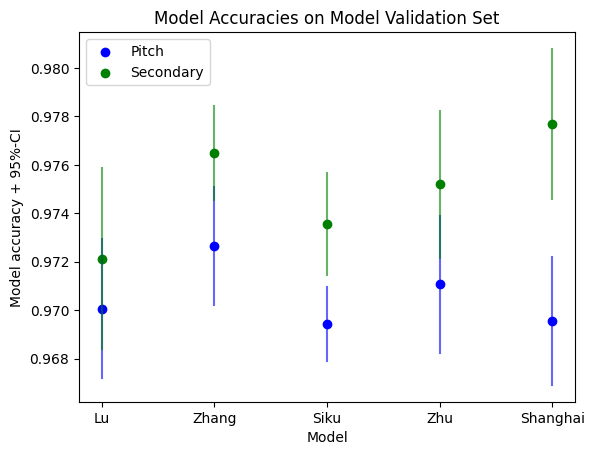

In [375]:
labels = ["Lu", "Zhang", "Siku", "Zhu", "Shanghai"]


values_pitch = get_means_and_confidences(model_1_val_pitch)
values_secondary = get_means_and_confidences(model_1_val_secondary)

xs = np.array(range(len(labels)))
offset = 0

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    plt.scatter(xs[idx], values_pitch[test_edition]["mean"], c="blue")
    plt.scatter(xs[idx], values_secondary[test_edition]["mean"], c="green")
    plt.xticks(xs, labels)

plt.title("Model Accuracies on Model Validation Set")

plt.ylabel("Model accuracy + 95%-CI")
plt.xlabel("Model")
plt.legend(["Pitch", "Secondary"])

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_pitch[test_edition]["mean"]-values_pitch[test_edition]["ci_length"], values_pitch[test_edition]["mean"]+values_pitch[test_edition]["ci_length"]),color='blue', alpha=.6)
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_secondary[test_edition]["mean"]-values_secondary[test_edition]["ci_length"], values_secondary[test_edition]["mean"]+values_secondary[test_edition]["ci_length"]),color='green', alpha=.6)
    print(test_edition)
    print(f"   pitch:     {values_pitch[test_edition]["mean"]*100:.2f}, {values_pitch[test_edition]["std"]*100:.2f}")
    print(f"   secondary: {values_secondary[test_edition]["mean"]*100:.2f}, {values_secondary[test_edition]["std"]*100:.2f}")
#plt.plot((xs[1]-offset, xs[1]-offset),(means_pitch_art[idx]-confidence_pitch_art[idx], means_pitch_art[idx]+confidence_pitch_art[idx]),color='blue', alpha=.6)
#plt.plot((xs[1]-offset, xs[1]-offset),(means_secondary_art[idx]-confidence_secondary_art[idx], means_secondary_art[idx]+confidence_secondary_art[idx]),color='green', alpha=.6)

plt.savefig("validation_accuracies.pdf", format="pdf", bbox_inches="tight")

{'Lu': [tensor(0.9455), tensor(0.9511), tensor(0.9497), tensor(0.9518), tensor(0.9511), tensor(0.9378), tensor(0.9441), tensor(0.9406), tensor(0.9434), tensor(0.9441), tensor(0.9399), tensor(0.9462), tensor(0.9441), tensor(0.9462), tensor(0.9462), tensor(0.9392), tensor(0.9448), tensor(0.9434), tensor(0.9448), tensor(0.9448), tensor(0.9372), tensor(0.9427), tensor(0.9413), tensor(0.9434), tensor(0.9434)], 'Zhang': [tensor(0.9537), tensor(0.9523), tensor(0.9502), tensor(0.9509), tensor(0.9559), tensor(0.9404), tensor(0.9376), tensor(0.9348), tensor(0.9369), tensor(0.9411), tensor(0.9516), tensor(0.9495), tensor(0.9474), tensor(0.9474), tensor(0.9523), tensor(0.9446), tensor(0.9432), tensor(0.9418), tensor(0.9418), tensor(0.9474), tensor(0.9509), tensor(0.9481), tensor(0.9460), tensor(0.9453), tensor(0.9509)], 'Siku': [tensor(0.9465), tensor(0.9395), tensor(0.9444), tensor(0.9388), tensor(0.9423), tensor(0.9451), tensor(0.9353), tensor(0.9409), tensor(0.9346), tensor(0.9388), tensor(0.94

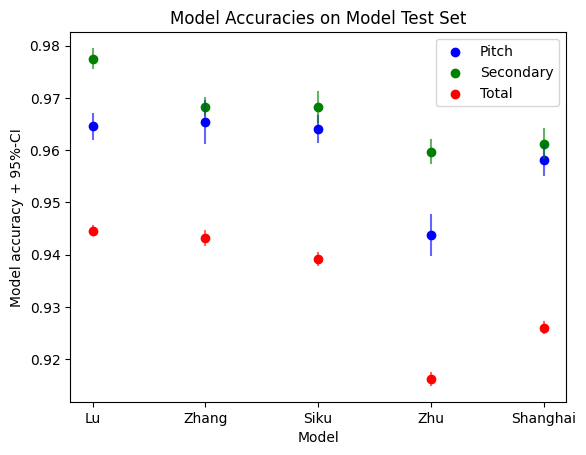

In [378]:
labels_lower = ["lu", "zhang", "siku", "zhu", "shanghai"]

values_pitch = get_means_and_confidences(model_1_test_pitch)
values_secondary = get_means_and_confidences(model_1_test_secondary)
print({test_edition: double_test_values_total[test_edition.lower()]["total"] for test_edition in labels})
values_total = get_means_and_confidences({test_edition: double_test_values_all[test_edition.lower()]["total"] for test_edition in labels_lower})


labels = ["Lu", "Zhang", "Siku", "Zhu", "Shanghai"]
xs = np.array(range(len(labels)))
offset = 0

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    
    plt.scatter(xs[idx], values_pitch[test_edition]["mean"], c="blue")
    plt.scatter(xs[idx], values_secondary[test_edition]["mean"], c="green")
    plt.scatter(xs[idx], values_total[test_edition]["mean"], c="red")

    plt.xticks(xs, labels)

plt.title("Model Accuracies on Model Test Set")

plt.ylabel("Model accuracy + 95%-CI")
plt.xlabel("Model")
plt.legend(["Pitch", "Secondary", "Total"])

for idx, test_edition in enumerate(labels):
    test_edition = test_edition.lower()
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_pitch[test_edition]["mean"]-values_pitch[test_edition]["ci_length"], values_pitch[test_edition]["mean"]+values_pitch[test_edition]["ci_length"]),color='blue', alpha=.6)
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_secondary[test_edition]["mean"]-values_secondary[test_edition]["ci_length"], values_secondary[test_edition]["mean"]+values_secondary[test_edition]["ci_length"]),color='green', alpha=.6)
    plt.plot((xs[idx]-offset, xs[idx]-offset),(values_total[test_edition]["mean"]-values_total[test_edition]["ci_length"], values_total[test_edition]["mean"]+values_total[test_edition]["ci_length"]),color='red', alpha=.6)
    print(test_edition)
    print(f"   pitch:     {values_pitch[test_edition]["mean"]*100:.2f}, {values_pitch[test_edition]["std"]*100:.2f}")
    print(f"   secondary: {values_secondary[test_edition]["mean"]*100:.2f}, {values_secondary[test_edition]["std"]*100:.2f}")
    print(f"   total:     {values_total[test_edition]["mean"]*100:.2f}, {values_total[test_edition]["std"]*100:.2f}")
#plt.plot((xs[1]-offset, xs[1]-offset),(means_pitch_art[idx]-confidence_pitch_art[idx], means_pitch_art[idx]+confidence_pitch_art[idx]),color='blue', alpha=.6)
#plt.plot((xs[1]-offset, xs[1]-offset),(means_secondary_art[idx]-confidence_secondary_art[idx], means_secondary_art[idx]+confidence_secondary_art[idx]),color='green', alpha=.6)

plt.savefig("test_accuracies.pdf", format="pdf", bbox_inches="tight")

In [52]:
from scipy.stats import bootstrap, ranksums, median_test
import numpy as np

with open("study_statistics.json", "r") as file_handle:
    study_statistics = json.load(file_handle)

sample = np.array([s["total_accuracy"] for s in study_statistics["all"]])/100
sample_pitch = np.array([s["pitch_accuracy"] for s in study_statistics["all"]])/100
sample_secondary = np.array([s["secondary_accuracy"] for s in study_statistics["all"]])/100

tested_shanghai_dataset = get_all_dataloaders(total_dataset, test_edition=Editions.SHANGHAI, image_size=48, transformations=transformations)["full"]["test"].dataset

sample_dataset_size = [719, 720]*10
sample_time = np.array(
        [s["real_time"]/sample_dataset_size[idx]*len(tested_shanghai_dataset) for idx, s in enumerate(study_statistics["all"])]
    )

print(sample)
print(study_statistics["average"].keys())

print("time", sample_time.mean()*60, "+-", sample_time.std()*60, "min")
print("pitch", sample_pitch.mean()*100, "+-", sample_pitch.std()*100, "%")
print("secondary", sample_secondary.mean()*100, "+-", sample_secondary.std()*100, "%")
print("total", sample.mean()*100, "+-", sample.std()*100, "%")


[0.72083333 0.91376912 0.9        0.52573018 0.89722222 0.9054242
 0.85277778 0.84840056 0.92361111 0.89568846 0.80138889 0.87482615
 0.9125     0.79972184 0.84583333]
dict_keys(['total_time', 'real_time', 'progress', 'total_accuracy', 'simple_accuracy', 'composite_accuracy', 'pitch_accuracy', 'secondary_accuracy'])
time 152.5300353194845 +- 38.628186160026225 s
pitch 87.18519806315356 +- 9.950612687005538 %
secondary 90.79878174419204 +- 5.043330113732578 %
total 84.11818111574718 +- 9.982785369212387 %


In [139]:
xs = double_test_values_total["shanghai"]["total"]
ys = sample
ranksums(xs, ys)

RanksumsResult(statistic=np.float64(5.210290006441054), pvalue=np.float64(1.8854567817416876e-07))

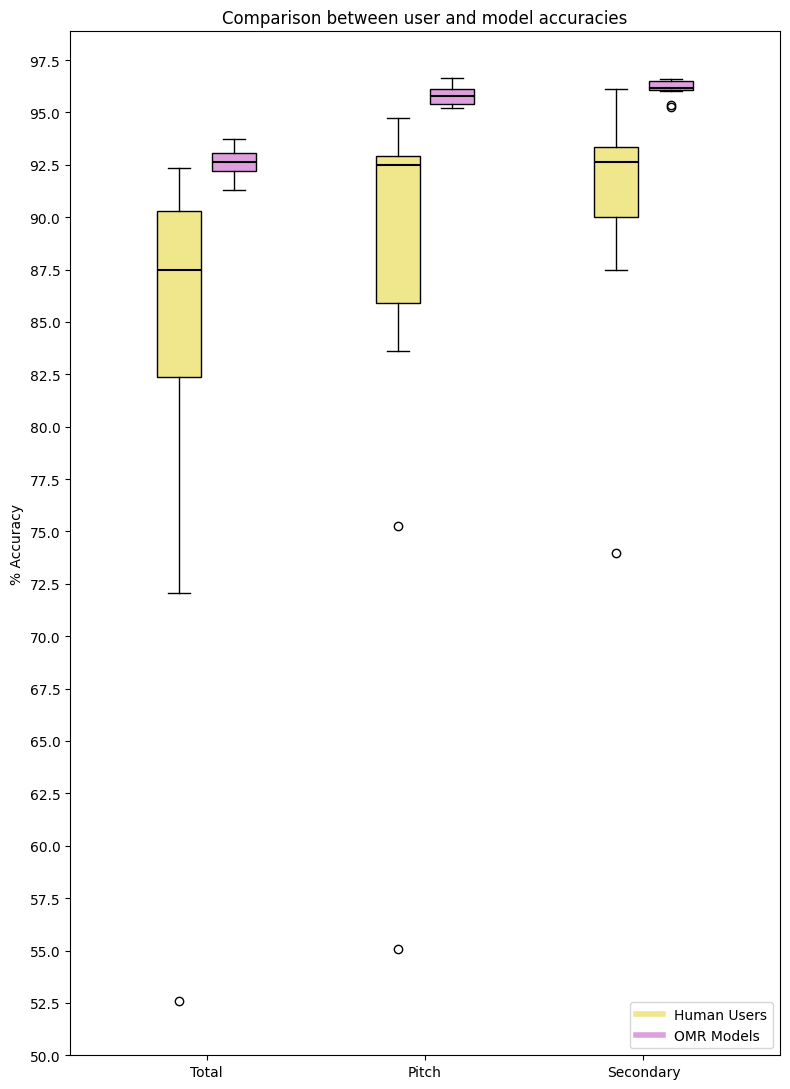

In [310]:
#double_test_values_total["shanghai"]

real_dict = {
    "Total": sample,
    "Pitch": sample_pitch,
    "Secondary": sample_secondary
}

ai_dict_all = {
    "Total": double_test_values_all["shanghai"]["total"],
    "Pitch": model_1_test_pitch["shanghai"],
    "Secondary": model_1_test_secondary["shanghai"]
}

ai_dict_best5 = {
    "Total": double_test_values_total["shanghai"]["total"],
    "Pitch": double_test_values_total["shanghai"]["pitch"][0:5],
    "Secondary": double_test_values_total["shanghai"]["secondary"][0:5]
}

keys = list(real_dict.keys())
x_positions = np.arange(len(keys))

# Create positions for the boxplots
width = 0.2  # Width of each boxplot
gap = 0.05
positions_1 = x_positions - (width+gap) / 2  # Positions for dict_1
#positions_2 = x_positions  # Positions for dict_2
positions_2 = x_positions + (width+gap) / 2  # Positions for dict_2

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 11))

# Custom mean properties
median_props = dict(color="black", linestyle="-", linewidth=1.5)

# Plot boxplots
bp1 = ax.boxplot([np.array(real_dict[k])*100 for k in keys],
                 positions=positions_1,
                 widths=width,
                 patch_artist=True,
                 boxprops=dict(facecolor="khaki", alpha=1),
                 medianprops=median_props)
bp2 = ax.boxplot([np.array(ai_dict_all[k])*100 for k in keys],
                 positions=positions_2,
                 widths=width,
                 patch_artist=True,
                 boxprops=dict(facecolor="plum", alpha=1),
                 medianprops=median_props)

# Customizing the plot
ax.set_xticks(x_positions)
ax.set_xticklabels(keys)
#ax.set_xlabel('Keys')
ax.set_ylabel('% Accuracy')
#ax.set_yticks(np.linspace(5, 100, num=50))
ax.set_yticks(np.linspace(50, 97.5, num=20))
ax.set_title('Comparison between user and model accuracies')

# Add a legend
handles = [plt.Line2D([0], [0], color='khaki', lw=4, label='Human Users'),
           plt.Line2D([0], [0], color='plum', lw=4, label='OMR Models'),
          ]
           #plt.Line2D([0], [0], color='lightgreen', lw=4, label='OMR Models (Best 5)'),]
ax.legend(handles=handles, loc='lower right')

# Show the plot
plt.tight_layout()
plt.savefig("study_accuracies.pdf")

plt.show()


#print(model_1_test_secondary["shanghai"])

In [6]:
import torch
orig = torch.ones((10, 3, 128, 128))
recon = torch.ones((5, 10, 3, 128, 128))

.shape

torch.Size([3, 128, 1280])

In [18]:
collected_losses = []

num_realizations, num_patches, _, _, _ = recon.shape

full_orig = torch.cat([orig[n] for n in range(num_patches)], dim=-1)
full_recon = torch.cat([recon[0][n] for n in range(num_patches)], dim=-1)

for realization_idx in range(num_realizations):
    single_realization_losses = []
    for patch_idx in range(num_patches):
        curr_orig = orig[patch_idx]
        curr_recon = recon[realization_idx, patch_idx]
        single_realization_losses.append(float(torch.sum(torch.abs(curr_orig - curr_recon))))
    collected_losses.append(single_realization_losses)
# collected_losses has shape [num_realizations, num_patches]
collected_losses = torch.Tensor(collected_losses)
loss = collected_losses.min(dim=0).values # for each patch, get minimal reconstruction loss
loss = torch.max(loss) # get maximum difference as loss
print(loss)

tensor(0.)
